<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Decision Tree - Diabetes
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
">
Carga de librerias y del conjunto de datos
</h2>

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report)

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
 📥 Carga de datos guardados del EDA
</h2>

In [18]:
BASE_PATH = "../data/processed/diabetes_decision_tree/"

df = pd.read_csv(f"{BASE_PATH}diabetes_ready.csv")
X_train = pd.read_csv(f"{BASE_PATH}X_train.csv")
X_test = pd.read_csv(f"{BASE_PATH}X_test.csv")
y_train = pd.read_csv(f"{BASE_PATH}y_train.csv").squeeze("columns")
y_test = pd.read_csv(f"{BASE_PATH}y_test.csv").squeeze("columns")

print("Shape de df:", df.shape)
print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

display(df.head())

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nDistribucion de y_train:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribucion de y_test:")
print(y_test.value_counts(normalize=True).sort_index())

Shape de df: (768, 9)
Shape de X_train: (614, 8)
Shape de X_test: (154, 8)
Shape de y_train: (614,)
Shape de y_test: (154,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Columnas del dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Distribucion de y_train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Distribucion de y_test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
">
Entrenamiento del modelo base
</h2>

In [7]:
tree_base = DecisionTreeClassifier(random_state=42)

tree_base.fit(X_train, y_train)

y_train_pred = tree_base.predict(X_train)
y_test_pred = tree_base.predict(X_test)

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui entrenamos el primer arbol de decision con su configuracion base. Este modelo nos sirve como punto de partida para ver que tan bien aprende el patron de los datos antes de hacer ajustes.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien generamos predicciones para entrenamiento y prueba. Esto es importante porque nos permitira comparar ambos resultados y detectar si existe <b>overfitting</b>, es decir, si el modelo memoriza demasiado el conjunto de entrenamiento.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Metricas del modelo base
</h4>

In [8]:
metrics_base = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "precision": [
        precision_score(y_train, y_train_pred, zero_division=0),
        precision_score(y_test, y_test_pred, zero_division=0)
    ],
    "recall": [
        recall_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0)
    ],
    "f1": [
        f1_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0)
    ]
})

metrics_base

,dataset,accuracy,precision,recall,f1
0,train,1.000000,1.000000,1.000000,1.000000
1,test,0.681818,0.553191,0.481481,0.514851


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este primer arbol parecia muy bueno al entrenarlo, pero en realidad se aprendio demasiado los datos. Por eso, cuando lo probe con datos nuevos, ya no rindio tan bien y ademas dejo pasar varios casos de diabetes. En resumen, no conviene quedarnos con este modelo y lo correcto es hacerlo mas simple para que funcione mejor fuera del entrenamiento.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Profundidad y numero de hojas del arbol base
</h4>

In [9]:
print("Profundidad del arbol:", tree_base.get_depth())
print("Numero de hojas:", tree_base.get_n_leaves())

Profundidad del arbol: 14
Numero de hojas: 111


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Se aprecia que el arbol crecio demasiado. Con una profundidad de <span style="color:#D11A2A; font-weight:700;">14</span> y <span style="color:#D11A2A; font-weight:700;">111 hojas</span>, queda claro que el modelo se complico mas de la cuenta y termino aprendiendose los datos. En resumen, este arbol esta demasiado grande y mi siguiente paso es hacerlo mas simple probando <span style="color:#D11A2A; font-weight:700;">max_depth</span>.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Prueba de distintos valores de max_depth
</h4>

In [10]:
depth_results = []

for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred_depth = model.predict(X_train)
    y_test_pred_depth = model.predict(X_test)

    depth_results.append({
        "max_depth": depth,
        "accuracy_train": accuracy_score(y_train, y_train_pred_depth),
        "accuracy_test": accuracy_score(y_test, y_test_pred_depth),
        "f1_train": f1_score(y_train, y_train_pred_depth, zero_division=0),
        "f1_test": f1_score(y_test, y_test_pred_depth, zero_division=0)
    })

depth_results = pd.DataFrame(depth_results)
depth_results

,max_depth,accuracy_train,accuracy_test,f1_train,f1_test
0,1,0.760586,0.694805,0.530351,0.389610
1,2,0.763844,0.688312,0.533762,0.368421
2,3,0.768730,0.688312,0.541935,0.368421
3,4,0.794788,0.785714,0.712329,0.691589
4,5,0.814332,0.759740,0.763485,0.678261
5,6,0.850163,0.746753,0.754011,0.561798
6,7,0.879479,0.753247,0.821256,0.604167
7,8,0.915309,0.714286,0.875000,0.531915
8,9,0.939739,0.720779,0.911695,0.516854
9,10,0.962541,0.675325,0.945107,0.489796


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui veo una mejora clara. Al ajustar <span style="color:#D11A2A; font-weight:700;">max_depth</span>, el arbol funciona mejor en <span style="color:#D11A2A; font-weight:700;">test</span>. El mejor punto aparece en <span style="color:#D11A2A; font-weight:700;">max_depth = 4</span>, con <span style="color:#D11A2A; font-weight:700;">accuracy_test = 0.7857</span> y <span style="color:#D11A2A; font-weight:700;">f1_test = 0.6916</span>. En resumen, este valor deja un modelo mas equilibrado y claramente mejor que el arbol base.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
📈 Visualizacion del efecto de max_depth
</h4>

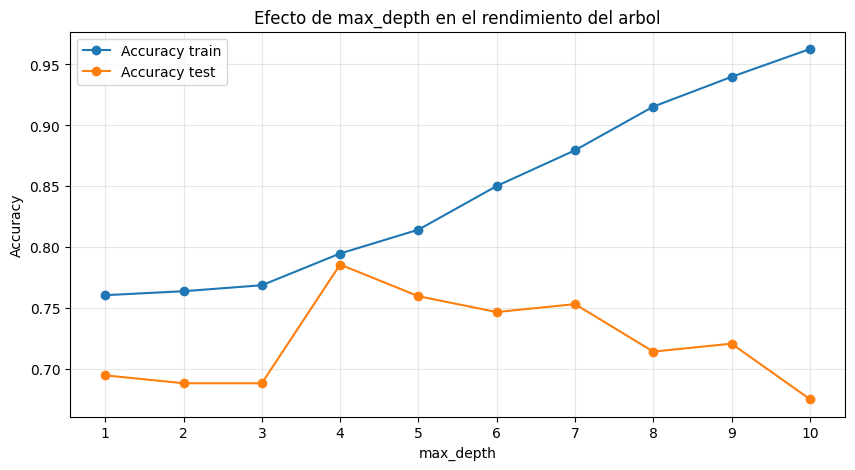

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(depth_results["max_depth"], depth_results["accuracy_train"], marker="o", label="Accuracy train")
plt.plot(depth_results["max_depth"], depth_results["accuracy_test"], marker="o", label="Accuracy test")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Efecto de max_depth en el rendimiento del arbol")
plt.xticks(depth_results["max_depth"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este grafico muestra algo importante: cuando el arbol crece, <span style="color:#D11A2A; font-weight:700;">train</span> sigue mejorando, pero <span style="color:#D11A2A; font-weight:700;">test</span> no. El mejor punto aparece en <span style="color:#D11A2A; font-weight:700;">max_depth = 4</span>. Desde ahi en adelante, el modelo se complica mas, mejora en entrenamiento, pero ya no responde mejor con datos nuevos.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Entrenamiento del modelo ajustado
</h4>

In [12]:
tree_tuned = DecisionTreeClassifier(max_depth=4, random_state=42)

tree_tuned.fit(X_train, y_train)

y_train_pred_tuned = tree_tuned.predict(X_train)
y_test_pred_tuned = tree_tuned.predict(X_test)

metrics_tuned = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train, y_train_pred_tuned),
        accuracy_score(y_test, y_test_pred_tuned)
    ],
    "precision": [
        precision_score(y_train, y_train_pred_tuned, zero_division=0),
        precision_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "recall": [
        recall_score(y_train, y_train_pred_tuned, zero_division=0),
        recall_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "f1": [
        f1_score(y_train, y_train_pred_tuned, zero_division=0),
        f1_score(y_test, y_test_pred_tuned, zero_division=0)
    ]
})

metrics_tuned

,dataset,accuracy,precision,recall,f1
0,train,0.794788,0.696429,0.728972,0.712329
1,test,0.785714,0.698113,0.685185,0.691589


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este resultado confirma que el modelo ajustado quedo mejor que el arbol base. En <span style="color:#D11A2A; font-weight:700;">test</span> sube a <span style="color:#D11A2A; font-weight:700;">accuracy = 0.7857</span> y <span style="color:#D11A2A; font-weight:700;">f1 = 0.6916</span>, asi que responde mejor con datos nuevos. En resumen, usar <span style="color:#D11A2A; font-weight:700;">max_depth = 4</span> fue una buena decision porque dejo un modelo mas equilibrado y mas confiable.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
📈 Matriz de confusion del modelo ajustado
</h4>

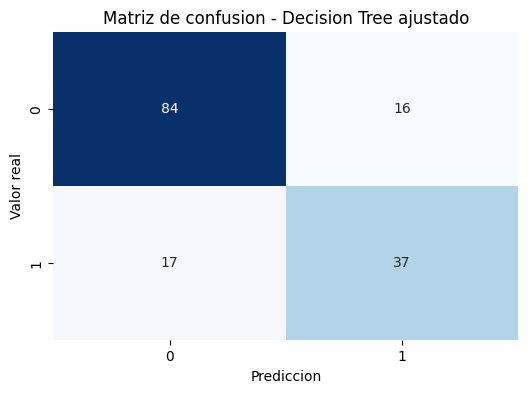

In [13]:
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusion - Decision Tree ajustado")
plt.xlabel("Prediccion")
plt.ylabel("Valor real")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Esta matriz confirma que el modelo esta bastante equilibrado. Acierta <span style="color:#D11A2A; font-weight:700;">84</span> casos sin diabetes y <span style="color:#D11A2A; font-weight:700;">37</span> con diabetes. Los errores tambien quedan bastante parejos, con <span style="color:#D11A2A; font-weight:700;">16 falsos positivos</span> y <span style="color:#D11A2A; font-weight:700;">17 falsos negativos</span>. En resumen, el modelo mejoro, aunque todavia debo indagar mas por esos casos de diabetes que no logro detectar el modelo.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Reporte de clasificacion del modelo ajustado
</h4>

In [14]:
print(classification_report(y_test, y_test_pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.84      0.84       100
           1       0.70      0.69      0.69        54

    accuracy                           0.79       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.79      0.79       154



<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Este reporte confirma que el modelo funciona bastante bien, con una <span style="color:#D11A2A; font-weight:700;">accuracy = 0.79</span>. Aun asi, noto que detecta mejor la clase <span style="color:#D11A2A; font-weight:700;">0</span> que la clase <span style="color:#D11A2A; font-weight:700;">1</span>. En resumen, el modelo quedo mas equilibrado que el arbol base, pero todavia tiene mas margen de mejora al detectar los casos de diabetes.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Importancia de las variables
</h4>

In [15]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree_tuned.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
1,Glucose,0.669671
5,BMI,0.168210
7,Age,0.118860
4,Insulin,0.043259
3,SkinThickness,0.000000
2,BloodPressure,0.000000
0,Pregnancies,0.000000
6,DiabetesPedigreeFunction,0.000000


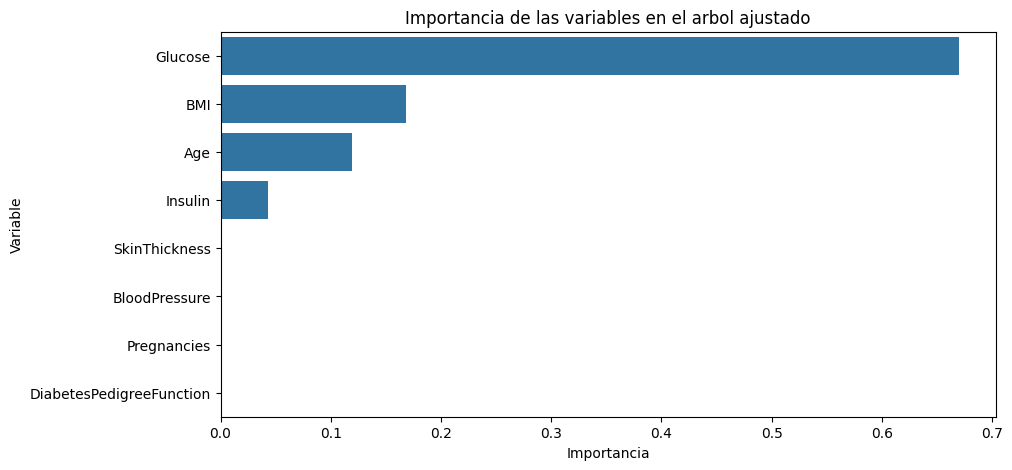

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance, x="importance", y="feature")
plt.title("Importancia de las variables en el arbol ajustado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Aqui queda claro que la variable mas importante es <span style="color:#D11A2A; font-weight:700;">Glucose</span>, con mucha diferencia sobre las demas. Luego aportan <span style="color:#D11A2A; font-weight:700;">BMI</span>, <span style="color:#D11A2A; font-weight:700;">Age</span> e <span style="color:#D11A2A; font-weight:700;">Insulin</span>, pero con bastante menos peso. En resumen, este arbol toma casi todas sus decisiones apoyandose sobre todo en <span style="color:#D11A2A; font-weight:700;">Glucose</span>.
  </p>
</div>

<h4 style="
  color: #ffffff;
  background: linear-gradient(135deg, #1f2937 0%, #111827 100%);
  padding: 10px 14px;
  border-radius: 8px;
  border-left: 5px solid #38bdf8;
  margin: 0;
">
Comparacion entre el modelo base y el modelo ajustado
</h4>

In [17]:
comparison_models = pd.DataFrame({
    "modelo": ["Base", "Ajustado (max_depth=4)"],
    "accuracy_test": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_tuned)
    ],
    "precision_test": [
        precision_score(y_test, y_test_pred, zero_division=0),
        precision_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "recall_test": [
        recall_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred_tuned, zero_division=0)
    ],
    "f1_test": [
        f1_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred_tuned, zero_division=0)
    ]
})

comparison_models

,modelo,accuracy_test,precision_test,recall_test,f1_test
0,Base,0.681818,0.553191,0.481481,0.514851
1,Ajustado (max_depth=4),0.785714,0.698113,0.685185,0.691589


<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Esta comparacion confirma la mejora. El modelo <span style="color:#D11A2A; font-weight:700;">ajustado</span> rinde mejor que el modelo <span style="color:#D11A2A; font-weight:700;">base</span> en <span style="color:#D11A2A; font-weight:700;">test</span>, con una <span style="color:#D11A2A; font-weight:700;">accuracy</span> que sube de <span style="color:#D11A2A; font-weight:700;">0.6818</span> a <span style="color:#D11A2A; font-weight:700;">0.7857</span> y un <span style="color:#D11A2A; font-weight:700;">f1</span> que pasa de <span style="color:#D11A2A; font-weight:700;">0.5149</span> a <span style="color:#D11A2A; font-weight:700;">0.6916</span>. En resumen, el arbol con <span style="color:#D11A2A; font-weight:700;">max_depth = 4</span> es la mejor opcion de las dos.
  </p>
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 0;
  font-size: 20px;
">
Conclusiones finales del proyecto
</h2>

<div style="
  background: #ececec;
  border-left: 6px solid #22c55e;
  border-radius: 12px;
  padding: 16px 18px;
  box-shadow: 0 8px 24px rgba(15,23,42,.08);
  margin: 6px 0 2px 0;
">
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En este proyecto use un <span style="color:#D11A2A; font-weight:700;">Decision Tree Classifier</span> para predecir <span style="color:#D11A2A; font-weight:700;">Outcome</span>. Al principio, el arbol base parecia muy bueno, pero en realidad estaba aprendiendo demasiado el entrenamiento y por eso rendia peor cuando lo probaba con datos nuevos.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Cuando ajuste <span style="color:#D11A2A; font-weight:700;">max_depth</span>, encontre que el mejor punto estaba en <span style="color:#D11A2A; font-weight:700;">max_depth = 4</span>. Con ese cambio, el modelo mejoro de forma clara en <span style="color:#D11A2A; font-weight:700;">test</span>, llegando a una <span style="color:#D11A2A; font-weight:700;">accuracy = 0.79</span> y un <span style="color:#D11A2A; font-weight:700;">f1 = 0.69</span>. Para mi, eso deja claro que recortar el arbol fue la decision correcta.
  </p>
  <p style="margin: 0 0 10px 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Tambien identifique que la variable mas importante fue <span style="color:#D11A2A; font-weight:700;">Glucose</span>, seguida por <span style="color:#D11A2A; font-weight:700;">BMI</span>, <span style="color:#D11A2A; font-weight:700;">Age</span> e <span style="color:#D11A2A; font-weight:700;">Insulin</span>. Eso me dice que el modelo basa casi todas sus decisiones en esas variables, sobre todo en <span style="color:#D11A2A; font-weight:700;">Glucose</span>.
  </p>
  <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    En conclusion, me quedo con el <span style="color:#D11A2A; font-weight:700;">modelo ajustado</span> porque fue el que dio el mejor equilibrio entre simplicidad y rendimiento. No es perfecto, y todavia le cuesta mas detectar algunos casos de diabetes que los casos sin diabetes, pero si representa una mejora real frente al modelo base. Para mi, este resultado es una base solida y bien justificada para cerrar el proyecto.
  </p>
    <p style="margin: 0; line-height: 1.75; color: #111827; font-size: 16px;">
    Investigue bastante sobre este tema y vi que hay muchas formas de mejorar el modelo. Sin embargo, eso implica probar mas modelos y ajustar mas parametros con mayor detalle.
  </p>
</div>